# Modelling Horn like geometry

Modelling Horn like geometry for meep with polar (cylinder coordinates)

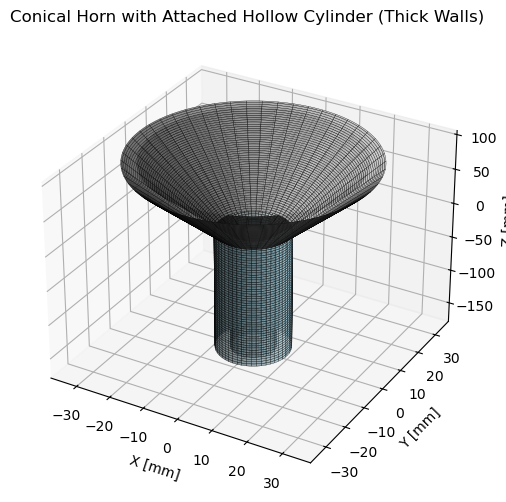

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Horn dimensions (example from figure b) ---
R_aperture = 33       # mm (outer radius at mouth)
R_throat = 10      # mm (outer radius at throat)
L = 100               # mm (axial length)

# Wall thickness
wall_thickness = 4.0  # mm

# Cylinder dimensions
cyl_radius_outer = R_throat                 # same as horn throat radius (outer)
cyl_radius_inner = cyl_radius_outer - wall_thickness
cyl_height = 1.73 * L   # cylinder height (1.73 × horn height)

# piecewise function r(z) for outer and inner surfaces
def r_outer(z):
    return R_throat + (R_aperture - R_throat) * (z / L)

def r_inner(z):
    return r_outer(z) - wall_thickness

# --- Cylindrical coordinates ---
nz = 150   # number of z samples
nphi = 150 # number of angular samples
phi = np.linspace(0, 2*np.pi, nphi)

# Horn section (outer)
z_horn = np.linspace(0, L, nz)
Z_horn, PHI_horn = np.meshgrid(z_horn, phi)
R_horn_outer = r_outer(Z_horn)
X_horn_outer = R_horn_outer * np.cos(PHI_horn)
Y_horn_outer = R_horn_outer * np.sin(PHI_horn)

# Horn section (inner)
R_horn_inner = r_inner(Z_horn)
X_horn_inner = R_horn_inner * np.cos(PHI_horn)
Y_horn_inner = R_horn_inner * np.sin(PHI_horn)

# Cylinder section (outer)
z_cyl = np.linspace(-cyl_height, 0, nz)
Z_cyl, PHI_cyl = np.meshgrid(z_cyl, phi)
R_cyl_outer = cyl_radius_outer * np.ones_like(Z_cyl)
X_cyl_outer = R_cyl_outer * np.cos(PHI_cyl)
Y_cyl_outer = R_cyl_outer * np.sin(PHI_cyl)

# Cylinder section (inner)
R_cyl_inner = cyl_radius_inner * np.ones_like(Z_cyl)
X_cyl_inner = R_cyl_inner * np.cos(PHI_cyl)
Y_cyl_inner = R_cyl_inner * np.sin(PHI_cyl)

# --- Plot ---
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# horn outer surface
ax.plot_surface(X_horn_outer, Y_horn_outer, Z_horn, color='silver', edgecolor='k', alpha=0.8, linewidth=0.2)
# horn inner surface
ax.plot_surface(X_horn_inner, Y_horn_inner, Z_horn, color='silver', edgecolor='k', alpha=0.6, linewidth=0.2)

# cylinder outer surface
ax.plot_surface(X_cyl_outer, Y_cyl_outer, Z_cyl, color='lightblue', edgecolor='k', alpha=0.7, linewidth=0.2)
# cylinder inner surface
ax.plot_surface(X_cyl_inner, Y_cyl_inner, Z_cyl, color='lightblue', edgecolor='k', alpha=0.5, linewidth=0.2)

# formatting
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_zlabel('Z [mm]')
ax.set_title('Conical Horn with Attached Hollow Cylinder (Thick Walls)')

plt.show()
